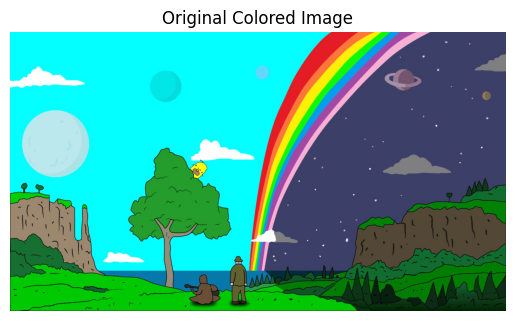

In [8]:
from PIL import Image
import matplotlib.pyplot as plt
image_colored = Image.open("/content/drive/MyDrive/AI ML/Data/BigLezShow.jpg")
plt.imshow(image_colored)
plt.title("Original Colored Image")
plt.axis("off")
plt.show()

In [9]:
print ( " Image Format : " , image_colored . format )
print ( " Image Size : " , image_colored . size )
print ( " Image Mode : " , image_colored . mode )

 Image Format :  JPEG
 Image Size :  (1920, 1080)
 Image Mode :  RGB


In [10]:
# Get the size (width, height) and channels (RGB)
width, height = image_colored.size
channels= len (image_colored.getbands())
print(f"Image shape (RGB) :({height} , {width} , {channels})")
image_size_colored = width*height*3
print(f"Image size (RGB) : {image_size_colored}")

Image shape (RGB) :(1080 , 1920 , 3)
Image size (RGB) : 6220800


In [11]:
import numpy as np
image_colored_np = np.array(image_colored)
image_colored_np.shape
print("Shape of the image array: ",image_colored_np.shape)

Shape of the image array:  (1080, 1920, 3)


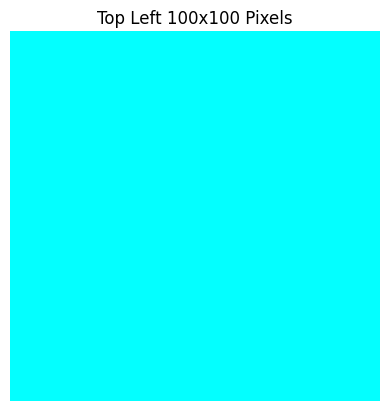

In [12]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Re-defining image_colored and image_colored_np to ensure they are available
image_colored_np = np.array(image_colored)

image_array = image_colored_np

top_left = image_array[0:100, 0:100]

plt.imshow(top_left)
plt.title("Top Left 100x100 Pixels")
plt.axis("off")
plt.show()

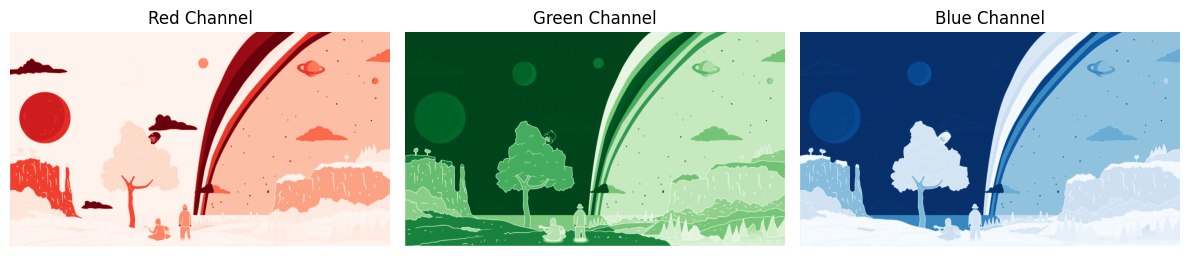

In [13]:
red_channel = image_array[:, :, 0]
green_channel = image_array[:, :, 1]
blue_channel = image_array[:, :, 2]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(red_channel, cmap="Reds")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(green_channel, cmap="Greens")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(blue_channel, cmap="Blues")
plt.title("Blue Channel")
plt.axis("off")

plt.tight_layout()
plt.show()

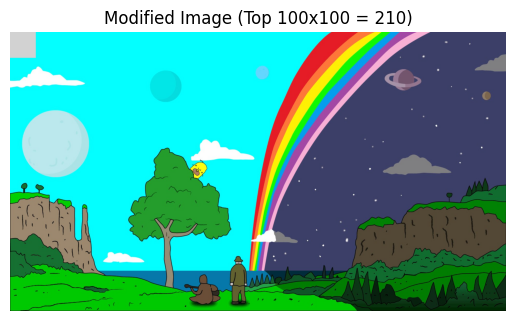

In [14]:
modified_image = image_array.copy()

modified_image[0:100, 0:100] = 210

plt.imshow(modified_image)
plt.title("Modified Image (Top 100x100 = 210)")
plt.axis("off")
plt.show()

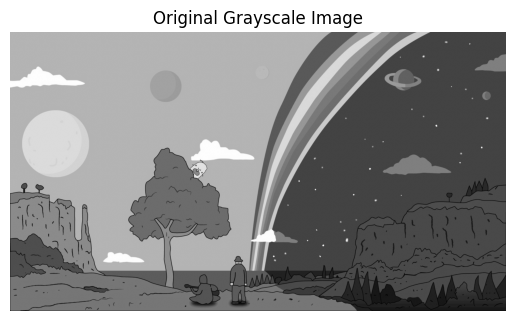

In [16]:
image_grayed = image_colored.convert("L")
image_array_grayed = np.array(image_grayed)
plt.imshow(image_array_grayed, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()


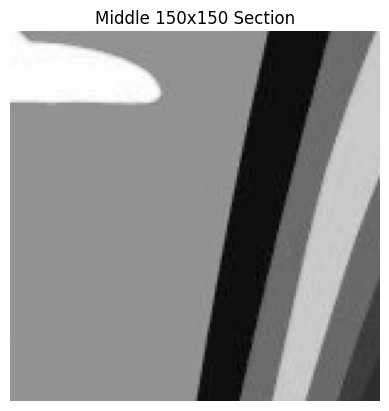

In [17]:
height, width = image_array_grayed.shape

center_h = height // 2
center_w = width // 2

middle_section = image_array_grayed[
    center_h-75:center_h+75,
    center_w-75:center_w+75
]

plt.imshow(middle_section, cmap="gray")
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).
• Apply a threshold to the grayscale image: set all pixel values below 100 to 0, and all values above 100 to 255 (creating a binary image).

• Display the resulting binary image.

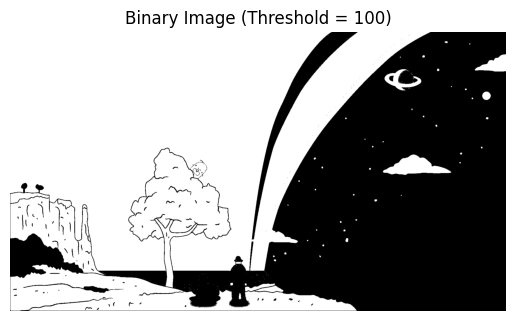

In [18]:
binary_image = np.where(image_array_grayed < 100, 0, 255)

plt.imshow(binary_image, cmap="gray")
plt.title("Binary Image (Threshold = 100)")
plt.axis("off")
plt.show()

Rotate the image 90 degrees clockwise and display the result.
• Rotate the image by 90 degrees clockwise using the Pillow rotate method or by manipulating the image array.

• Display the rotated image using matplotlib.

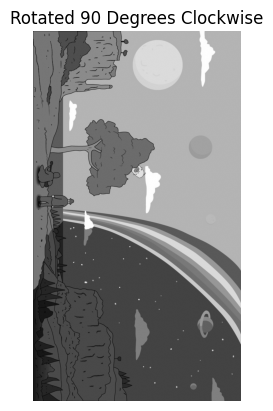

In [19]:
rotated_image = image_grayed.rotate(-90, expand=True)

plt.imshow(rotated_image, cmap="gray")
plt.title("Rotated 90 Degrees Clockwise")
plt.axis("off")
plt.show()

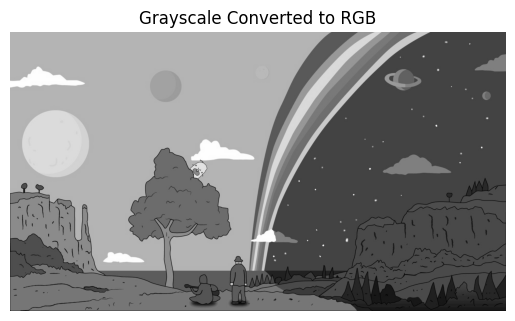

In [20]:
rgb_image = image_grayed.convert("RGB")

plt.imshow(rgb_image)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

In [34]:
print("RGB Image Mode:", rgb_image.mode)
print("Number of bands (channels) in RGB image:", len(rgb_image.getbands()))

RGB Image Mode: RGB
Number of bands (channels) in RGB image: 3


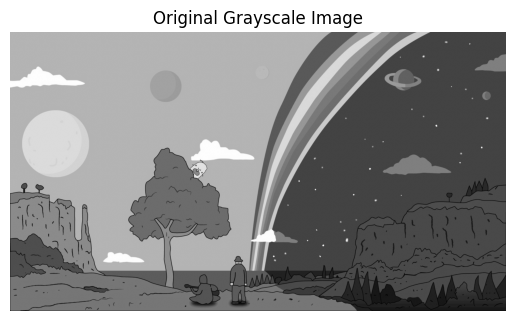

In [22]:
image_grayed = image_colored.convert("L")
image_array = np.array(image_grayed)

height, width = image_array.shape

data = image_array.reshape(height, width)

plt.imshow(image_array, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()


In [35]:
mean = np.mean(data, axis=0)
centered_data = data - mean

In [24]:
cov_matrix = np.cov(centered_data, rowvar=False)

print("Covariance Matrix Shape:", cov_matrix.shape)

Covariance Matrix Shape: (1920, 1920)


In [25]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

print("Eigenvalues Shape:", eigenvalues.shape)
print("Eigenvectors Shape:", eigenvectors.shape)

Eigenvalues Shape: (1920,)
Eigenvectors Shape: (1920, 1920)


In [26]:
sorted_indices = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]


k = 50
top_k_eigenvectors = eigenvectors[:, :k]

print("Top k Eigenvectors Shape:", top_k_eigenvectors.shape)


Top k Eigenvectors Shape: (1920, 50)


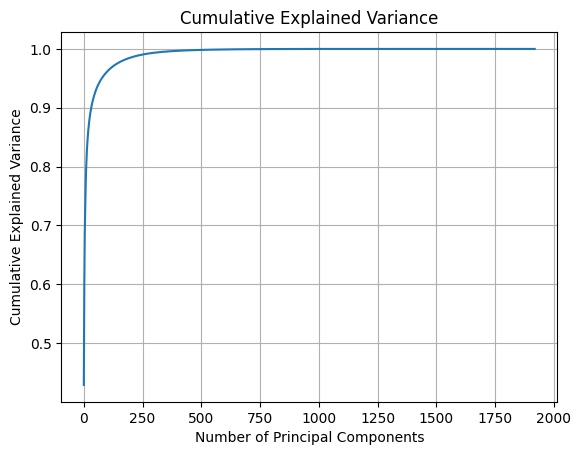

In [27]:
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

cumulative_variance = np.cumsum(explained_variance_ratio)

plt.plot(cumulative_variance)
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [29]:
compressed_data = np.dot(centered_data, top_k_eigenvectors)

print("Compressed Data Shape:", compressed_data.shape)

Compressed Data Shape: (1080, 50)


In [30]:
reconstructed_image = np.dot(compressed_data, top_k_eigenvectors.T) + mean

print("Reconstructed Image Shape:", reconstructed_image.shape)


Reconstructed Image Shape: (1080, 1920)


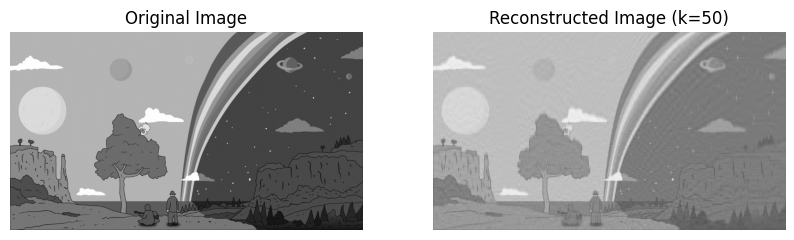

In [31]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(reconstructed_image, cmap="gray")
plt.title(f"Reconstructed Image (k={k})")
plt.axis("off")

plt.show()

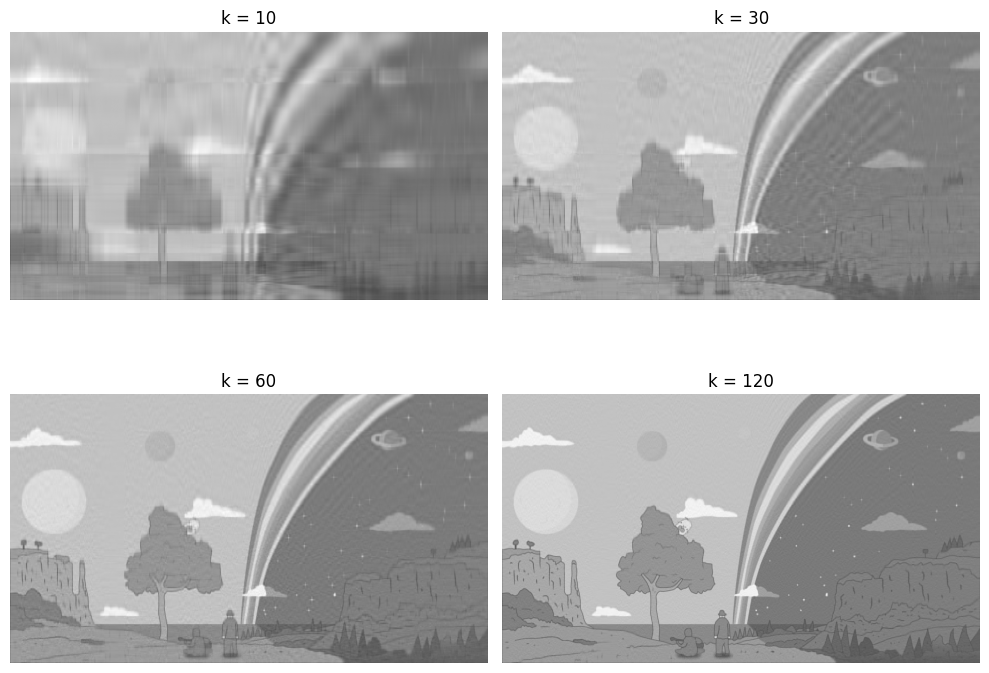

In [32]:
k_values = [10, 30, 60, 120]

plt.figure(figsize=(10,8))

for i, k in enumerate(k_values):
    components = eigenvectors[:, :k]
    compressed = np.dot(centered_data, components)
    reconstructed = np.dot(compressed, components.T) + mean

    plt.subplot(2,2,i+1)
    plt.imshow(reconstructed, cmap="gray")
    plt.title(f"k = {k}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [36]:
k_values = [10, 30, 60, 120]

print("--- Evaluation of Image Compression ---")
for k in k_values:
    # Reconstruct the image with the current k value
    # 'centered_data', 'eigenvectors', 'mean' are available from previous cells.
    components = eigenvectors[:, :k]
    compressed = np.dot(centered_data, components)
    reconstructed = np.dot(compressed, components.T) + mean

    # Calculate Mean Squared Error (MSE)
    # Ensure both arrays are of compatible types and shapes for subtraction
    # The reconstructed image might have float values, so cast original to float for accurate comparison
    mse = np.mean((image_array.astype(float) - reconstructed)**2)
    print(f"k = {k}: Mean Squared Error (MSE) = {mse:.2f}")

print("\n--- Qualitative Assessment ---")
print("As observed from the previously displayed images:")
print("- For small k (e.g., 10, 30), the image is highly compressed, leading to significant loss of detail and a blurry appearance.")
print("- As k increases (e.g., 60, 120), more principal components are retained, and the reconstructed image becomes progressively clearer and more similar to the original.")
print("- A balance needs to be struck between compression ratio (lower k) and image quality (higher k).")



--- Evaluation of Image Compression ---
k = 10: Mean Squared Error (MSE) = 339.30
k = 30: Mean Squared Error (MSE) = 167.12
k = 60: Mean Squared Error (MSE) = 99.34
k = 120: Mean Squared Error (MSE) = 49.31

--- Qualitative Assessment ---
As observed from the previously displayed images:
- For small k (e.g., 10, 30), the image is highly compressed, leading to significant loss of detail and a blurry appearance.
- As k increases (e.g., 60, 120), more principal components are retained, and the reconstructed image becomes progressively clearer and more similar to the original.
- A balance needs to be struck between compression ratio (lower k) and image quality (higher k).
